# Concave Closures from Hard $c$-Transforms

This notebook generates `fig:dual-alternating-c-transform-failure`.  For the bilinear cost
$$
    c(x,y)=-xy,
$$
the $c$-transform is a concave envelope operation on compact one-dimensional domains: $f^{c\bar c}$ is the smallest $c$-concave majorant of $f$, which here is the ordinary concave majorant.  This makes hard alternating best responses very abrupt: one closure removes non-concave oscillations, after which the process has essentially no gradual dynamics.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY,
    DIRAC_MARKER_SIZE, setup_matplotlib, figure_dir, save_pdf,
    box_axes, interp_color,
)

setup_matplotlib()

NAME = "dual-alternating-c-transform-failure"
OUT = figure_dir(NAME)


## Discretized bilinear transform

The grids for $x$ and $y$ are identical.  The source potential $f$ and target potential $g$ are deliberately non-concave, but they are now chosen with visibly different shapes.  We compute one-sided and double $c$-transforms for the bilinear cost $c(x,y)=-xy$.

In [2]:
x = np.linspace(-1.25, 1.25, 900)
y = x.copy()

# The two initial potentials are intentionally different: f has sharp asymmetric bumps,
# whereas g has a broad oscillatory shape. Both are non-concave.
f = (
    0.18 - 0.58 * x**2
    + 0.145 * np.sin(7.2 * x + 0.40)
    + 0.070 * np.sin(17.0 * x - 0.60)
    + 0.105 * np.exp(-58.0 * (x + 0.54)**2)
    - 0.150 * np.exp(-78.0 * (x - 0.28)**2)
)
f -= f.mean()

g = (
    -0.06 - 0.30 * (y + 0.25)**2
    + 0.175 * np.cos(5.0 * y - 0.25)
    - 0.095 * np.sin(14.5 * y + 0.45)
    + 0.155 * np.exp(-46.0 * (y - 0.72)**2)
)
g -= g.mean()


def c_transform(values, grid_from, grid_to):
    C = -grid_from[:, None] * grid_to[None, :]
    return (C - values[:, None]).min(axis=0)


fc = c_transform(f, x, y)
fcc = c_transform(fc, y, x)
gc = c_transform(g, y, x)
gcc = c_transform(gc, x, y)

# Vertical gauge shifts make the three curves in each panel comparable without changing their shape.
gc_vis = gc - np.median(gc - fcc)
fc_vis = fc - np.median(fc - gcc)

LEFT_MAIN = "#b2182b"
LEFT_DASH = "#ef8a62"
LEFT_CLOSURE = "#7f0000"
RIGHT_MAIN = "#2166ac"
RIGHT_DASH = "#67a9cf"
RIGHT_CLOSURE = "#053061"


## Export source and target panels

The source-side panel uses a reddish palette, and the target-side panel uses a blueish palette.  Mathematical labels are kept inside the figure because they identify the curves themselves; panel titles are supplied by LaTeX.

In [3]:
def finish_function_axis(ax, grid, curves):
    curves = np.vstack(curves)
    lo = curves.min() - 0.08
    hi = curves.max() + 0.08
    ax.set_xlim(grid.min(), grid.max())
    ax.set_ylim(lo, hi)
    ax.tick_params(labelbottom=False, labelleft=False)
    box_axes(ax)


fig, ax = plt.subplots(figsize=(2.72, 1.92))
ax.plot(x, f, color=LEFT_MAIN, lw=1.05, alpha=0.88, zorder=2)
ax.plot(x, gc_vis, color=LEFT_DASH, lw=1.05, linestyle=(0, (3.0, 2.0)), alpha=0.95, zorder=3)
ax.plot(x, fcc, color=LEFT_CLOSURE, lw=1.60, zorder=4)
finish_function_axis(ax, x, [f, gc_vis, fcc])
ax.text(x[-1] - 0.28, np.interp(x[-1] - 0.28, x, f), r"$f$", color=LEFT_MAIN, fontsize=8)
ax.text(x[-1] - 0.58, np.interp(x[-1] - 0.58, x, gc_vis) + 0.025, r"$g^{\bar c}$", color=LEFT_DASH, fontsize=8)
ax.text(x[42], np.interp(x[42], x, fcc) + 0.028, r"$f^{c\bar c}$", color=LEFT_CLOSURE, fontsize=8)
save_pdf(fig, OUT / "source-concave-closure.pdf", pad_inches=0.060)
plt.close(fig)

fig, ax = plt.subplots(figsize=(2.72, 1.92))
ax.plot(y, g, color=RIGHT_MAIN, lw=1.05, alpha=0.88, zorder=2)
ax.plot(y, fc_vis, color=RIGHT_DASH, lw=1.05, linestyle=(0, (3.0, 2.0)), alpha=0.95, zorder=3)
ax.plot(y, gcc, color=RIGHT_CLOSURE, lw=1.60, zorder=4)
finish_function_axis(ax, y, [g, fc_vis, gcc])
ax.text(y[-1] - 0.28, np.interp(y[-1] - 0.28, y, g), r"$g$", color=RIGHT_MAIN, fontsize=8)
ax.text(y[54], np.interp(y[54], y, fc_vis) + 0.035, r"$f^c$", color=RIGHT_DASH, fontsize=8)
ax.text(y[-1] - 0.64, np.interp(y[-1] - 0.64, y, gcc) + 0.026, r"$g^{\bar c c}$", color=RIGHT_CLOSURE, fontsize=8)
save_pdf(fig, OUT / "target-concave-closure.pdf", pad_inches=0.060)
plt.close(fig)


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


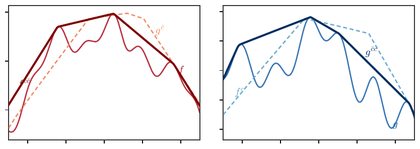

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/dual-alternating-c-transform-failure.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/dual-alternating-c-transform-failure.png")
display(Image(filename=str(_thumb)))
